In [ ]:
from executor import QuantumCircuit, QuantumOperator

from qiskit.circuit import ParameterVector

from executor.qulacs import QulacsCircuit, QulacsObservable

x = ParameterVector("x", 1)
p = ParameterVector("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.cry(0, 1, p[0] * x[0])
qc.rx(1, p[1] * x[0])
qc


     ┌───┐                                  
q_0: ┤ H ├────────■─────────────────────────
     └───┘┌───────┴───────┐┌───────────────┐
q_1: ─────┤ Ry(p[0]*x[0]) ├┤ Rx(p[1]*x[0]) ├
          └───────────────┘└───────────────┘

# Using Qulacs

In [ ]:
qulacs = QulacsCircuit(qc)

print("qulacs.circuit_arguments", qulacs.circuit_arguments)

qulacs._operation_list


qulacs.circuit_arguments ['p', 'x']


['h', 'ry', 'cx', 'ry', 'cx', 'rx']

In [ ]:
pop = ParameterVector("pop", 2)
operator = QuantumOperator(["ZI", "IZ"], [pop[0], pop[1]])


In [ ]:
from executor.qulacs.qulacs_executor import QulacsExecutor


executor = QulacsExecutor(seed=0, shots=10000)


executor.expectation_value(qc, operator, x=[0.1], p=[0.3, 0.4], pop=[0.5, 0.6])


np.float64(0.4994876517489877)

In [ ]:
executor.statevector(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5, 0.4],
)


array([6.98075107e-01-2.21098427e-18j, 6.84160081e-01-2.23810903e-02j,
       1.37005308e-17-1.12654984e-01j, 1.38686114e-01-1.10409385e-01j])

In [ ]:
executor.sample(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5, 0.4],
)


{np.str_('01'): 4675,
 np.str_('00'): 4880,
 np.str_('11'): 317,
 np.str_('10'): 128}

In [ ]:
executor.sample(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5, 0.4],
)


{np.str_('01'): 4749,
 np.str_('10'): 132,
 np.str_('00'): 4804,
 np.str_('11'): 315}

# Using Qoqo

In [ ]:
from executor.qoqo.qoqo_circuit import QoqoCircuit

qoqo = QoqoCircuit(qc)

# print("qoqo_circuit:", qoqo.get_qoqo_circuit())


[SparsePauliOp(['ZI', 'IZ'],
              coeffs=[ParameterExpression(1.0*pop[0]), ParameterExpression(1.0*pop[1])])]
[SparsePauliOp(['ZI', 'IZ'],
              coeffs=[(0.6+0j), (0.5+0j)])]
         ┌───┐                                        
q_0: ────┤ H ├──────■──────────────────■──────────────
     ┌───┴───┴───┐┌─┴─┐┌────────────┐┌─┴─┐┌──────────┐
q_1: ┤ Ry(0.015) ├┤ X ├┤ Ry(-0.015) ├┤ X ├┤ Rx(0.04) ├
     └───────────┘└───┘└────────────┘└───┘└──────────┘
Hadamard(Hadamard { qubit: 0 })
RotateY(RotateY { qubit: 1, theta: Float(0.015) })
CNOT(CNOT { control: 0, target: 1 })
RotateY(RotateY { qubit: 1, theta: Float(-0.015) })
CNOT(CNOT { control: 0, target: 1 })
RotateX(RotateX { qubit: 1, theta: Float(0.04000000000000001) })



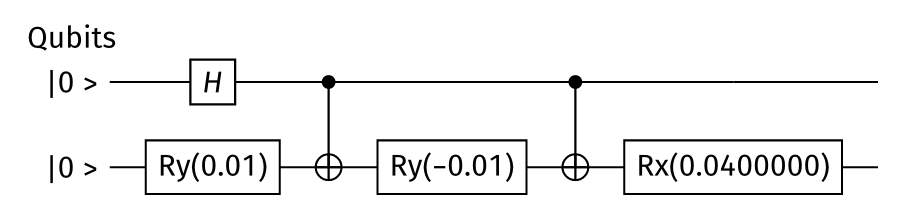

Observable: [SparsePauliOp(['ZI', 'IZ'],
              coeffs=[(0.6+0j), (0.5+0j)])]


0.49622

In [ ]:
from executor.qoqo.qoqo_executor import QoqoExecutor


executor = QoqoExecutor(seed=0, shots=10000)


executor.expectation_value(qc, operator, x=[0.1], p=[0.3, 0.4], pop=[0.5, 0.6])


In [ ]:
executor.statevector(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5],
)


[(0.7069653645442926+0j),
 (0.7068858324320252-0.0002121099381716985j),
 -0.014141192833545374j,
 (0.010604082804620574-0.014139601979180454j)]

In [ ]:
executor.sample(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5],
)


{np.str_('01'): 5004, np.str_('00'): 4987, np.str_('10'): 4, np.str_('11'): 5}

# Using Pennylane

In [ ]:
from executor.pennylane.pennylane_circuit import PennyLaneCircuit

pennylane_circuit = PennyLaneCircuit(qc)

pennylane_circuit.parameter_names

pennylane_circuit.build_pennylane_circuit()


<function executor.pennylane.pennylane_circuit.PennyLaneCircuit.build_pennylane_circuit.<locals>.pennylane_circuit(*args)>

In [ ]:
from executor.pennylane.pennylane_observable import PennyLaneObservable

pennylane_obs = PennyLaneObservable(operator)

pennylane_obs.parameter_names

pennylane_obs.build_pennylane_observable()


<function executor.pennylane.pennylane_observable.PennyLaneObservable.build_pennylane_observable.<locals>.pennylane_observable(*args)>

In [14]:
from executor.pennylane.pennylane_executor import PennylaneExecutor


executor = PennylaneExecutor(shots=10000, seed=0)


executor.expectation_value(
    qc,
    operator,
    pop=[0.5, 0.6],
    x=[0.1],
    p=[0.3],
)


TypeError: _lambdifygenerated() missing 1 required positional argument: 'Dummy_105'

In [ ]:
executor.statevector(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5],
)


In [ ]:
executor.sample(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5],
)


In [ ]:
executor.sample(
    qc,
    pop=[0.5, 0.6],
    x=[0.8],
    p=[0.5],
)
